### https://plotly.com/python/

In [4]:
# Bu kernelde plotly kütüphanesinin  nasıl kullanılacağını öğreneceğiz.

In [12]:
pip install plotly==3.10.0


Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/41.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.5 MB ? eta -:--:--
   - -------------------------------------- 1.0/41.5 MB 3.4 MB/s eta 0:00:13
   - -------------------------------------- 1.6/41.5 MB 3.4 MB/s eta 0:00:12
   -- ------------------------------------- 2.1/41.5 MB 2.6 MB/s eta 0:00:16
   -- ------------------------------------- 2.4/41.5 MB 2.5 MB/s eta 0:00:16
   -- ------------------------------------- 2.6/41.5 MB 2.3 MB/s eta 0:00:17
   --- ------------------------------------ 3.4/41.5 MB 2.4 MB/s eta 0:00:16
   ---- ----------------------------------- 4.5/41.5 MB 2.7 MB/s eta 0:00:14
   ----- ---------------------------------- 5.2/41.5 MB 2.8 MB/s eta 0:00:13
   ----- ---------------------------------- 6.0/41.5 MB 3.0 MB/s eta 0:00:12
   ------ ------

In [18]:
pip show plotly

Name: plotly
Version: 3.10.0
Summary: An open-source, interactive graphing library for Python
Home-page: https://plot.ly/python/
Author: Chris P
Author-email: chris@plot.ly
License: MIT
Location: C:\Users\Rasit\AppData\Roaming\Python\Python312\site-packages
Requires: decorator, nbformat, pytz, requests, retrying, six
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [24]:
!pip install wordcloud

import numpy as pd
import pandas as pd
# plotly
# import plotly.plotly as py
from plotly.offline import init_notebook_mode, iplot, plot
init_notebook_mode(connected=True)
import plotly.graph_objs as go

# word cloud library
from wordcloud import WordCloud

# matplotlib
import matplotlib.pyplot as plt

#import os
#print(os.listdir("../input"))

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


# Loading Data and Explanation of Features
<font color='blue'>
* timesData includes 14 features that are:
    <font color='black'>
    * world_rank             
    * university_name       
    * country               
    * teaching                
    * international            
    * research                 
    * citations                
    * income                   
    * total_score              
    * num_students             
    * student_staff_ratio      
    * international_students   
    * female_male_ratio        
    * year 

In [30]:
# Load data that we will use.
timesData = pd.read_csv("Plotly/timesData.csv")

In [32]:
timesData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2603 entries, 0 to 2602
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   world_rank              2603 non-null   object 
 1   university_name         2603 non-null   object 
 2   country                 2603 non-null   object 
 3   teaching                2603 non-null   float64
 4   international           2603 non-null   object 
 5   research                2603 non-null   float64
 6   citations               2603 non-null   float64
 7   income                  2603 non-null   object 
 8   total_score             2603 non-null   object 
 9   num_students            2544 non-null   object 
 10  student_staff_ratio     2544 non-null   float64
 11  international_students  2536 non-null   object 
 12  female_male_ratio       2370 non-null   object 
 13  year                    2603 non-null   int64  
dtypes: float64(4), int64(1), object(9)
memor

In [34]:
timesData.head()

,world_rank,university_name,country,teaching,international,research,citations,income,total_score,num_students,student_staff_ratio,international_students,female_male_ratio,year
0,1,Harvard University,United States of America,99.7,72.4,98.7,98.8,34.5,96.1,"20,152",8.9,25%,NaN,2011
1,2,California Institute of Technology,United States of America,97.7,54.6,98.0,99.9,83.7,96.0,"2,243",6.9,27%,33 : 67,2011
2,3,Massachusetts Institute of Technology,United States of America,97.8,82.3,91.4,99.9,87.5,95.6,"11,074",9.0,33%,37 : 63,2011
3,4,Stanford University,United States of America,98.3,29.5,98.1,99.2,64.3,94.3,"15,596",7.8,22%,42 : 58,2011
4,5,Princeton University,United States of America,90.9,70.3,95.4,99.9,-,94.2,"7,929",8.4,27%,45 : 55,2011



# Line Charts
<font color='red'>
Line Charts Example: Citation (Alıntı Yapma) and Teaching (Öğrenme) vs World Rank of Top 100 Universities
<font color='black'>
    
 1) Import graph_objs as *go*
 2) Creating traces
    * x = x axis
    * y = y axis
    * mode = type of plot like marker, line or line + markers ( line+ markers vb.)
    * name = name of the plots
    * marker = marker is used with dictionary. 
        * color = color of lines. It takes RGB (red, green, blue) and opacity (alpha)
    * text = The hover text (hover is curser)
* data = is a list that we add traces into it
* layout = it is dictionary.
    * title = title of layout
    * x axis = it is dictionary
        * title = label of x axis
        * ticklen = length of x axis ticks
        * zeroline = showing zero line or not
* fig = it includes data and layout
* iplot() = plots the figure(fig) that is created by data and layout

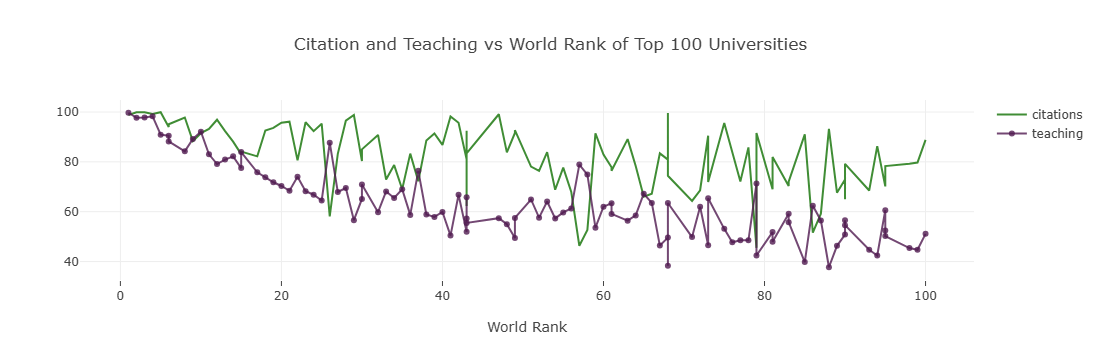

In [63]:
# prepare data frame
df = timesData.iloc[:100,:] # ilk 100 sample ve tüm featurlar

# import graph objects as "go"
import plotly.graph_objs as go

# boşluk doldurma gibi trace 1 , trace 2 , layout , figür
# Creating trace1 # kalıptır bunlar  istenen parametleri verirsin.
trace1 = go.Scatter(
                    x = df.world_rank,
                    y = df.citations,
                    mode = "lines",
                    name = "citations",
                    marker = dict(color = 'rgba(16, 112, 2, 0.8)'), # 0-255 arası
                    text= df.university_name)
# Creating trace2
trace2 = go.Scatter(
                    x = df.world_rank,
                    y = df.teaching,
                    mode = "lines+markers", # scatter pointler de var
                    name = "teaching",
                    marker = dict(color = 'rgba(80, 26, 80, 0.8)'),
                    text= df.university_name) # üzerine geldiğimizde görmek istediğimiz yazı

data = [trace1, trace2] # data adlı bir listede birleştirdik traceleri

layout = dict(title = 'Citation and Teaching vs World Rank of Top 100 Universities',
              xaxis= dict(title= 'World Rank',ticklen= 5,zeroline= False)
             )
fig = dict(data = data, layout = layout) # layout ile datayı birleştirip bir figür oluşturuyoruz.
iplot(fig) # dictionary kullanıldığına dikkat etmek lazım.

In [65]:
# Üniversitelerin dünya sıralaması 100 lere doğru gittiğinde citiaions çok değişmese de  teaching çok değişir.

In [67]:
df.head()

,world_rank,university_name,country,teaching,international,research,citations,income,total_score,num_students,student_staff_ratio,international_students,female_male_ratio,year
0,1,Harvard University,United States of America,99.7,72.4,98.7,98.8,34.5,96.1,"20,152",8.9,25%,NaN,2011
1,2,California Institute of Technology,United States of America,97.7,54.6,98.0,99.9,83.7,96.0,"2,243",6.9,27%,33 : 67,2011
2,3,Massachusetts Institute of Technology,United States of America,97.8,82.3,91.4,99.9,87.5,95.6,"11,074",9.0,33%,37 : 63,2011
3,4,Stanford University,United States of America,98.3,29.5,98.1,99.2,64.3,94.3,"15,596",7.8,22%,42 : 58,2011
4,5,Princeton University,United States of America,90.9,70.3,95.4,99.9,-,94.2,"7,929",8.4,27%,45 : 55,2011


In [69]:
df.tail() # ilk 100 üniversite 2011 yılına denk geliyor 

,world_rank,university_name,country,teaching,international,research,citations,income,total_score,num_students,student_staff_ratio,international_students,female_male_ratio,year
95,95,University of Arizona,United States of America,52.4,21.9,52.2,70.1,84.2,57.3,"36,429",12.7,8%,52 : 48,2011
96,95,University of Basel,Switzerland,50.2,91.3,37.1,78.3,45.8,57.3,"12,551",17.3,24%,54 : 46,2011
97,98,"University of Maryland, College Park",United States of America,45.4,35.4,48.6,79.2,-,57.2,"31,331",8.4,9%,48 : 52,2011
98,99,Dartmouth College,United States of America,44.7,31.0,49.2,79.7,-,57.1,"6,178",6.6,16%,47 : 53,2011
99,100,École Normale Supérieure de Lyon,France,51.1,37.6,34.4,88.8,26.1,57.0,"2,218",8.0,14%,49 : 51,2011



# Scatter
<font color='red'>
Scatter Example: Citation vs world rank of top 100 universities with 2014, 2015 and 2016 years
<font color='black'>
    
1) Import graph_objs as *go*
2) Creating traces
    * x = x axis
    * y = y axis
    * mode = type of plot like marker, line or line + markers
    * name = name of the plots
    * marker = marker is used with dictionary. 
        * color = color of lines. It takes RGB (red, green, blue) and opacity (alpha)
    * text = The hover text (hover is curser)
3 ) data = is a list that we add traces into it
4 )  layout = it is dictionary.
    * title = title of layout
    * x axis = it is dictionary
        * title = label of x axis
        * ticklen = length of x axis ticks
        * zeroline = showing zero line or not
    * y axis = it is dictionary and same with x axis
5 )fig = it includes data and layout 
6 )iplot() = plots the figure(fig) that is created by data and layout

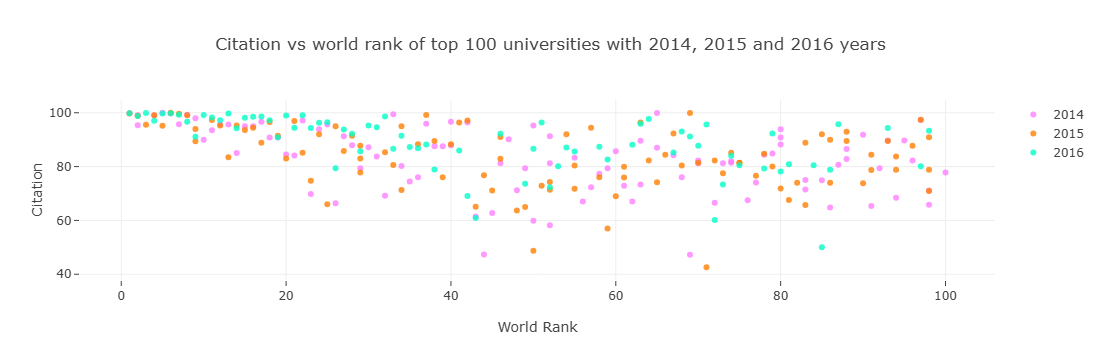

In [81]:
# prepare data frames
df2014 = timesData[timesData.year == 2014].iloc[:100,:]
df2015 = timesData[timesData.year == 2015].iloc[:100,:]
df2016 = timesData[timesData.year == 2016].iloc[:100,:]

# import graph objects as "go"
import plotly.graph_objs as go


# creating trace1
trace1 =go.Scatter(
                    x = df2014.world_rank,
                    y = df2014.citations,
                    mode = "markers",
                    name = "2014",
                    marker = dict(color = 'rgba(255, 128, 255, 0.8)'),
                    text= df2014.university_name)

# creating trace2
trace2 =go.Scatter(
                    x = df2015.world_rank,
                    y = df2015.citations,
                    mode = "markers",
                    name = "2015",
                    marker = dict(color = 'rgba(255, 128, 2, 0.8)'),
                    text= df2015.university_name)


# creating trace3
trace3 =go.Scatter(
                    x = df2016.world_rank,
                    y = df2016.citations,
                    mode = "markers",
                    name = "2016",
                    marker = dict(color = 'rgba(0, 255, 200, 0.8)'),
                    text= df2016.university_name)


data = [trace1, trace2, trace3]


layout = dict(title = 'Citation vs world rank of top 100 universities with 2014, 2015 and 2016 years',
              xaxis= dict(title= 'World Rank',ticklen= 5,zeroline= False),
              yaxis= dict(title= 'Citation',ticklen= 5,zeroline= False)
             )


fig = dict(data = data, layout = layout)
iplot(fig)

In [83]:
df2015.head()
# totalscore : dünya sıralaması 

,world_rank,university_name,country,teaching,international,research,citations,income,total_score,num_students,student_staff_ratio,international_students,female_male_ratio,year
1402,1,California Institute of Technology,United States of America,92.2,67.0,98.1,99.7,89.1,94.3,"2,243",6.9,27%,33 : 67,2015
1403,2,Harvard University,United States of America,92.9,67.6,98.6,98.9,44.0,93.3,"20,152",8.9,25%,NaN,2015
1404,3,University of Oxford,United Kingdom,88.6,90.7,97.7,95.5,72.9,93.2,"19,919",11.6,34%,46 : 54,2015
1405,4,Stanford University,United States of America,91.5,69.0,96.7,99.1,63.1,92.9,"15,596",7.8,22%,42 : 58,2015
1406,5,University of Cambridge,United Kingdom,89.7,87.8,95.6,95.2,51.1,92.0,"18,812",11.8,34%,46 : 54,2015



# Bar Charts
<font color='red'>
First Bar Charts Example: citations and teaching of top 3 universities in 2014(style1)

<font color='black'>

* 1) Import graph_objs as *go*
* 2) Creating traces
    * x = x axis
    * y = y axis
    * mode = type of plot like marker, line or line + markers
    * name = name of the plots
    * marker = marker is used with dictionary. 
        * color = color of lines. It takes RGB (red, green, blue) and opacity (alpha)
        * line = It is dictionary. line between bars
            * color = line color around bars
    * 3) text = The hover text (hover is curser)
* 4) data = is a list that we add traces into it
* 5) layout = it is dictionary.
    * barmode = bar mode of bars like grouped
* 6) fig = it includes data and layout
* 7) iplot() = plots the figure(fig) that is created by data and layout

In [87]:
# prepare data frames
df2014 = timesData[timesData.year == 2014].iloc[:3,:]
df2014

,world_rank,university_name,country,teaching,international,research,citations,income,total_score,num_students,student_staff_ratio,international_students,female_male_ratio,year
1002,1,California Institute of Technology,United States of America,94.4,65.8,98.2,99.8,91.2,94.9,"2,243",6.9,27%,33 : 67,2014
1003,2,Harvard University,United States of America,95.3,66.2,98.5,99.1,40.6,93.9,"20,152",8.9,25%,NaN,2014
1004,2,University of Oxford,United Kingdom,89.0,90.2,98.5,95.4,90.3,93.9,"19,919",11.6,34%,46 : 54,2014


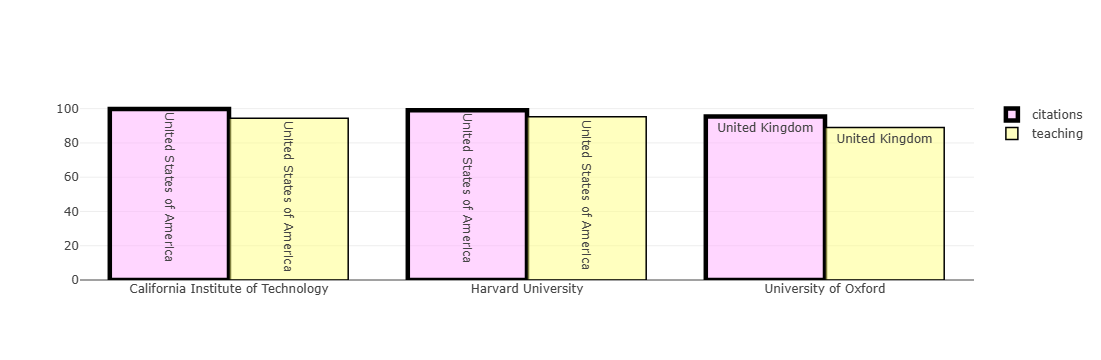

In [95]:
# prepare data frames
df2014 = timesData[timesData.year == 2014].iloc[:3,:]

# import graph objects as "go"
import plotly.graph_objs as go

# create trace1 
trace1 = go.Bar(
                x = df2014.university_name,
                y = df2014.citations,
                name = "citations",
                marker = dict(color = 'rgba(255, 174, 255, 0.5)',
                             line=dict(color='rgb(0,0,0)',width=4.5)), # bar plot çevresindeki renk ve kalınlık
                text = df2014.country) # hangi ülkeye ait olduğu yazsın.

# create trace2 
trace2 = go.Bar(
                x = df2014.university_name,
                y = df2014.teaching,
                name = "teaching",
                marker = dict(color = 'rgba(255, 255, 128, 0.5)',
                              line=dict(color='rgb(0,0,0)',width=1.5)),
                text = df2014.country)

data = [trace1, trace2]

layout = go.Layout(barmode = "group") # trace 1 ve trace 2 ' yi yan yana koy demiş.

fig = go.Figure(data = data, layout = layout)

iplot(fig)

In [91]:
# bar plot ile karşılaştırma yaptık.


Second Bar Charts Example: citations and teaching of top 3 universities in 2014 (style2)
<br> Actually, if you change only the barmode from *group* to *relative* in previous example, you achieve what we did here. However, for diversity I use different syntaxes.
    
<font color='black'>
           
* 1) Import graph_objs as *go*
* 2) Creating traces
    * x = x axis
    * y = y axis
    * name = name of the plots
    * type = type of plot like bar plot
* 3) data = is a list that we add traces into it
* 4) layout = it is dictionary.
    * xaxis = label of x axis
    * barmode = bar mode of bars like grouped( previous example) or relative
    * title = title of layout
* 5) fig = it includes data and layout
* 6) iplot() = plots the figure(fig) that is created by data and layout

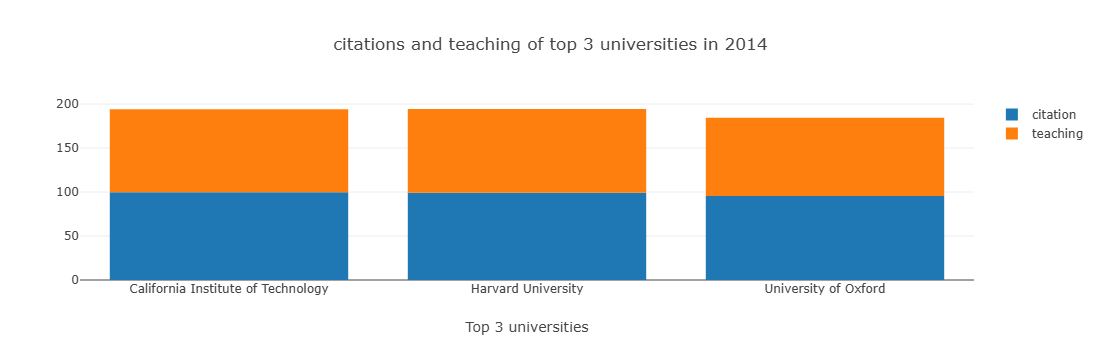

In [98]:
# prepare data frames
df2014 = timesData[timesData.year == 2014].iloc[:3,:]
# import graph objects as "go"
import plotly.graph_objs as go

x = df2014.university_name
# yukarıdakinden farklı şekilde trace oluşturuyoruz. Dictionary oluşturur gibi.
trace1 = {
  'x': x,
  'y': df2014.citations,
  'name': 'citation',
  'type': 'bar'
};
trace2 = {
  'x': x,
  'y': df2014.teaching,
  'name': 'teaching',
  'type': 'bar'
};
data = [trace1, trace2];
layout = {
  'xaxis': {'title': 'Top 3 universities'},
  'barmode': 'relative', # altlı üstlü şekilde göster
  'title': 'citations and teaching of top 3 universities in 2014'
};
fig = go.Figure(data = data, layout = layout)
iplot(fig)

"""<font color='red'>
Third Bar Charts Example: Horizontal bar charts.  (style3) Citation vs income for universities
<font color='black'>

* Import graph_objs as *go* and importing tools
    *  Tools: used for subplots
* Creating trace1 
    * bar: bar plot
        * x = x axis 
        * y = y axis
        * marker
            * color: color of bars
            * line: bar line color and width
        * name: name of bar
        * orientation: orientation like horizontal 
   * creating trace2
       * scatter: scatter plot
           * x = x axis 
            * y = y axis
            * mode: scatter type line line + markers or only markers
            * line: properties of line
                * color: color of line
            * name: name of scatter plot
    * layout: axis, legend, margin, paper and plot properties
        * """ 

In [103]:
"""# import graph objects as "go" and import tools
import plotly.graph_objs as go
from plotly import tools
import matplotlib.pyplot as plt
# prepare data frames
df2016 = timesData[timesData.year == 2016].iloc[:7,:]

y_saving = [each for each in df2016.research]
y_net_worth  = [float(each) for each in df2016.income]
x_saving = [each for each in df2016.university_name]
x_net_worth  = [each for each in df2016.university_name]
trace0 = go.Bar(
                x=y_saving,
                y=x_saving,
                marker=dict(color='rgba(171, 50, 96, 0.6)',line=dict(color='rgba(171, 50, 96, 1.0)',width=1)),
                name='research',
                orientation='h',
)
trace1 = go.Scatter(
                x=y_net_worth,
                y=x_net_worth,
                mode='lines+markers',
                line=dict(color='rgb(63, 72, 204)'),
                name='income',
)
layout = dict(
                title='Citations and income',
                yaxis=dict(showticklabels=True,domain=[0, 0.85]),
                yaxis2=dict(showline=True,showticklabels=False,linecolor='rgba(102, 102, 102, 0.8)',linewidth=2,domain=[0, 0.85]),
                xaxis=dict(zeroline=False,showline=False,showticklabels=True,showgrid=True,domain=[0, 0.42]),
                xaxis2=dict(zeroline=False,showline=False,showticklabels=True,showgrid=True,domain=[0.47, 1],side='top',dtick=25),
                legend=dict(x=0.029,y=1.038,font=dict(size=10) ),
                margin=dict(l=200, r=20,t=70,b=70),
                paper_bgcolor='rgb(248, 248, 255)',
                plot_bgcolor='rgb(248, 248, 255)',
)
annotations = []
y_s = np.round(y_saving, decimals=2)
y_nw = np.rint(y_net_worth)
# Adding labels
for ydn, yd, xd in zip(y_nw, y_s, x_saving):
    # labeling the scatter savings
    annotations.append(dict(xref='x2', yref='y2', y=xd, x=ydn - 4,text='{:,}'.format(ydn),font=dict(family='Arial', size=12,color='rgb(63, 72, 204)'),showarrow=False))
    # labeling the bar net worth
    annotations.append(dict(xref='x1', yref='y1', y=xd, x=yd + 3,text=str(yd),font=dict(family='Arial', size=12,color='rgb(171, 50, 96)'),showarrow=False))

layout['annotations'] = annotations

# Creating two subplots
fig = tools.make_subplots(rows=1, cols=2, specs=[[{}, {}]], shared_xaxes=True,
                          shared_yaxes=False, vertical_spacing=0.001)

fig.append_trace(trace0, 1, 1)
fig.append_trace(trace1, 1, 2)

fig['layout'].update(layout)
iplot(fig)"""

'# import graph objects as "go" and import tools\nimport plotly.graph_objs as go\nfrom plotly import tools\nimport matplotlib.pyplot as plt\n# prepare data frames\ndf2016 = timesData[timesData.year == 2016].iloc[:7,:]\n\ny_saving = [each for each in df2016.research]\ny_net_worth  = [float(each) for each in df2016.income]\nx_saving = [each for each in df2016.university_name]\nx_net_worth  = [each for each in df2016.university_name]\ntrace0 = go.Bar(\n                x=y_saving,\n                y=x_saving,\n                marker=dict(color=\'rgba(171, 50, 96, 0.6)\',line=dict(color=\'rgba(171, 50, 96, 1.0)\',width=1)),\n                name=\'research\',\n                orientation=\'h\',\n)\ntrace1 = go.Scatter(\n                x=y_net_worth,\n                y=x_net_worth,\n                mode=\'lines+markers\',\n                line=dict(color=\'rgb(63, 72, 204)\'),\n                name=\'income\',\n)\nlayout = dict(\n                title=\'Citations and income\',\n            

# Pie Charts
<font color='red'>
Pie Charts Example: Students rate of top 7 universities in 2016
<font color='black'>

* fig: create figures
    * data: plot type
        * values: values of plot
        * labels: labels of plot
        * name: name of plots
        * hoverinfo: information in hover
        * hole: hole width
        * type: plot type like pie
  
    * layout: layout of plot
        * title: title of layout
        * annotations: font, showarrow, text, x, y

In [116]:
# data preparation
df2016 = timesData[timesData.year == 2016].iloc[:7,:]
df2016.info()
# num students  bakıcaz

<class 'pandas.core.frame.DataFrame'>
Index: 7 entries, 1803 to 1809
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   world_rank              7 non-null      object 
 1   university_name         7 non-null      object 
 2   country                 7 non-null      object 
 3   teaching                7 non-null      float64
 4   international           7 non-null      object 
 5   research                7 non-null      float64
 6   citations               7 non-null      float64
 7   income                  7 non-null      object 
 8   total_score             7 non-null      object 
 9   num_students            7 non-null      object 
 10  student_staff_ratio     7 non-null      float64
 11  international_students  7 non-null      object 
 12  female_male_ratio       6 non-null      object 
 13  year                    7 non-null      int64  
dtypes: float64(4), int64(1), object(9)
memory usa

In [122]:
df2016.head()
# 2,243 --> 2.243 e çevrilmeli.

,world_rank,university_name,country,teaching,international,research,citations,income,total_score,num_students,student_staff_ratio,international_students,female_male_ratio,year
1803,1,California Institute of Technology,United States of America,95.6,64.0,97.6,99.8,97.8,95.2,"2,243",6.9,27%,33 : 67,2016
1804,2,University of Oxford,United Kingdom,86.5,94.4,98.9,98.8,73.1,94.2,"19,919",11.6,34%,46 : 54,2016
1805,3,Stanford University,United States of America,92.5,76.3,96.2,99.9,63.3,93.9,"15,596",7.8,22%,42 : 58,2016
1806,4,University of Cambridge,United Kingdom,88.2,91.5,96.7,97.0,55.0,92.8,"18,812",11.8,34%,46 : 54,2016
1807,5,Massachusetts Institute of Technology,United States of America,89.4,84.0,88.6,99.7,95.4,92.0,"11,074",9.0,33%,37 : 63,2016


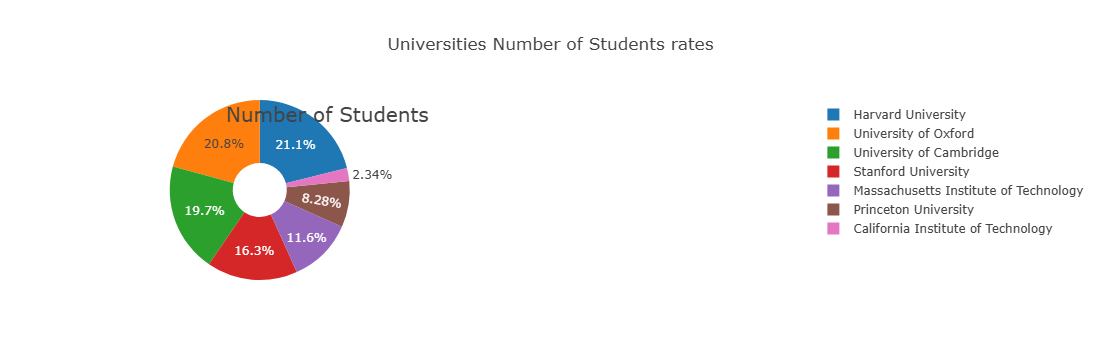

In [108]:
# data preparation
df2016 = timesData[timesData.year == 2016].iloc[:7,:] # 2016 yılındaki top 7 üniversitenin öğrenci sayılarına bakıyoruz.

# trace-data-figure yönteminden farklı bir yönteme bakıyoruz.
# tek trace oluşturduğumuz için direkt data içine oluşturucaz .
pie1 = df2016.num_students
pie1_list = [float(each.replace(',', '.')) for each in df2016.num_students]  # str(2,4) => str(2.4) = > float(2.4) = 2.4
labels = df2016.university_name

# figure
fig = {
  "data": [
    {
      "values": pie1_list,
      "labels": labels,
      "domain": {"x": [0, .5]},
      "name": "Number Of Students Rates",
      "hoverinfo":"label+percent+name",
      "hole": .3,
      "type": "pie"
    },],
  "layout": {
        "title":"Universities Number of Students rates",
        "annotations": [
            { "font": { "size": 20},
              "showarrow": False,
              "text": "Number of Students",
                "x": 0.20,
                "y": 1
            },
        ]
    }
}

iplot(fig)

In [128]:
df2016.head(7)

,world_rank,university_name,country,teaching,international,research,citations,income,total_score,num_students,student_staff_ratio,international_students,female_male_ratio,year
1803,1,California Institute of Technology,United States of America,95.6,64.0,97.6,99.8,97.8,95.2,"2,243",6.9,27%,33 : 67,2016
1804,2,University of Oxford,United Kingdom,86.5,94.4,98.9,98.8,73.1,94.2,"19,919",11.6,34%,46 : 54,2016
1805,3,Stanford University,United States of America,92.5,76.3,96.2,99.9,63.3,93.9,"15,596",7.8,22%,42 : 58,2016
1806,4,University of Cambridge,United Kingdom,88.2,91.5,96.7,97.0,55.0,92.8,"18,812",11.8,34%,46 : 54,2016
1807,5,Massachusetts Institute of Technology,United States of America,89.4,84.0,88.6,99.7,95.4,92.0,"11,074",9.0,33%,37 : 63,2016
1808,6,Harvard University,United States of America,83.6,77.2,99.0,99.8,45.2,91.6,"20,152",8.9,25%,NaN,2016
1809,7,Princeton University,United States of America,85.1,78.5,91.9,99.3,52.1,90.1,"7,929",8.4,27%,45 : 55,2016


In [124]:
pie1 = df2016.num_students
pie1

1803     2,243
1804    19,919
1805    15,596
1806    18,812
1807    11,074
1808    20,152
1809     7,929
Name: num_students, dtype: object

In [126]:
pie1_list

[2.243, 19.919, 15.596, 18.812, 11.074, 20.152, 7.929]

In [140]:
import numpy as np
np.sum(pie1_list)
# 20.152*100/95.7249999994 bize öğrenci sayısını vermiş pie chart direkt bu işlemi yapıp oranı verir

95.725

In [148]:
np.sum(pie1_list)
20.152*100/95.7249999994
# harvard university oranı ile öğrenci sayısı tutması üzerine 
# pie plot orantısal olarak veriyor. Bizim ona kaç tane öğrenci olduğunu yazmamız yeterli

21.051971794334094


# Bubble Charts
<font color='red'>
Bubble Charts Example: University world rank (first 20) vs teaching score with number of students(size) and international score (color) in 2016
<font color='black'>
    
* x = x axis
* y = y axis
* mode = markers(scatter)
*  marker = marker properties
    * color = third dimension of plot. Internaltional score
    * size = fourth dimension of plot. Number of students
* text: university names
* Scatter ile çok benzer renk ve size'a anlam katılır. 

In [156]:
df2016.info()
# , ---> . olmalı

<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, 1803 to 1822
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   world_rank              20 non-null     object 
 1   university_name         20 non-null     object 
 2   country                 20 non-null     object 
 3   teaching                20 non-null     float64
 4   international           20 non-null     object 
 5   research                20 non-null     float64
 6   citations               20 non-null     float64
 7   income                  20 non-null     object 
 8   total_score             20 non-null     object 
 9   num_students            20 non-null     object 
 10  student_staff_ratio     20 non-null     float64
 11  international_students  20 non-null     object 
 12  female_male_ratio       17 non-null     object 
 13  year                    20 non-null     int64  
dtypes: float64(4), int64(1), object(9)
memory us

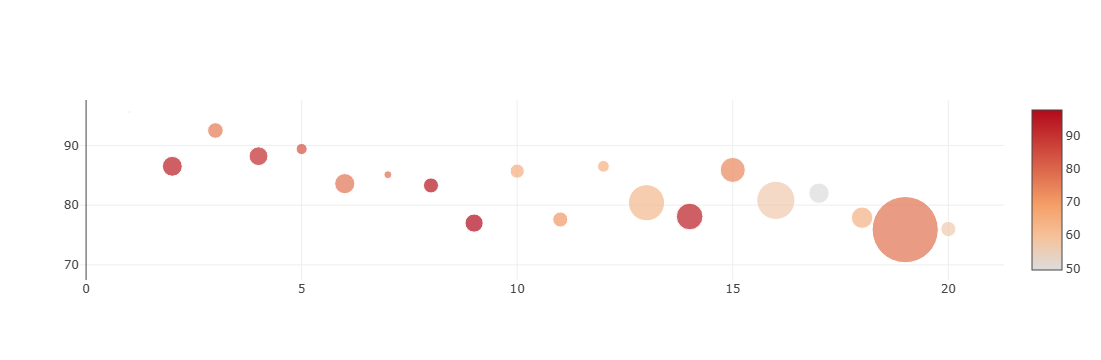

In [158]:
# data preparation
df2016 = timesData[timesData.year == 2016].iloc[:20,:]

num_students_size  = [float(each.replace(',', '.')) for each in df2016.num_students]
international_color = [float(each) for each in df2016.international]

data = [
    {
        'y': df2016.teaching,
        'x': df2016.world_rank,
        'mode': 'markers',
        'marker': {
            'color': international_color,
            'size': num_students_size,
            'showscale': True
        },
        "text" :  df2016.university_name    
    }
]
# layout oluşturmadığımız için figüre içine koymamıza gerek yok.
# layout= 
# fig = fig[data=data]
iplot(data)

In [162]:
df2016.head(20)

,world_rank,university_name,country,teaching,international,research,citations,income,total_score,num_students,student_staff_ratio,international_students,female_male_ratio,year
1803,1,California Institute of Technology,United States of America,95.6,64.0,97.6,99.8,97.8,95.2,"2,243",6.9,27%,33 : 67,2016
1804,2,University of Oxford,United Kingdom,86.5,94.4,98.9,98.8,73.1,94.2,"19,919",11.6,34%,46 : 54,2016
1805,3,Stanford University,United States of America,92.5,76.3,96.2,99.9,63.3,93.9,"15,596",7.8,22%,42 : 58,2016
1806,4,University of Cambridge,United Kingdom,88.2,91.5,96.7,97.0,55.0,92.8,"18,812",11.8,34%,46 : 54,2016
1807,5,Massachusetts Institute of Technology,United States of America,89.4,84.0,88.6,99.7,95.4,92.0,"11,074",9.0,33%,37 : 63,2016
1808,6,Harvard University,United States of America,83.6,77.2,99.0,99.8,45.2,91.6,"20,152",8.9,25%,NaN,2016
1809,7,Princeton University,United States of America,85.1,78.5,91.9,99.3,52.1,90.1,"7,929",8.4,27%,45 : 55,2016
1810,8,Imperial College London,United Kingdom,83.3,96.0,88.5,96.7,53.7,89.1,"15,060",11.7,51%,37 : 63,2016
1811,9,ETH Zurich – Swiss Federal Institute of Techno...,Switzerland,77.0,97.9,95.0,91.1,80.0,88.3,"18,178",14.7,37%,31 : 69,2016
1812,10,University of Chicago,United States of America,85.7,65.0,88.9,99.2,36.6,87.9,"14,221",6.9,21%,42 : 58,2016



# Histogram
<font color='red'>
Lets look at histogram of students-staff ratio in 2011 and 2012 years. 
    <font color='black'>
               
* trace1 = first histogram
    * x = x axis
    * y = y axis
    * opacity = opacity of histogram
    * name = name of legend
    * marker = color of histogram
* trace2 = second histogram
* layout = layout 
    * barmode = mode of histogram like overlay. Also you can change it with *stack*

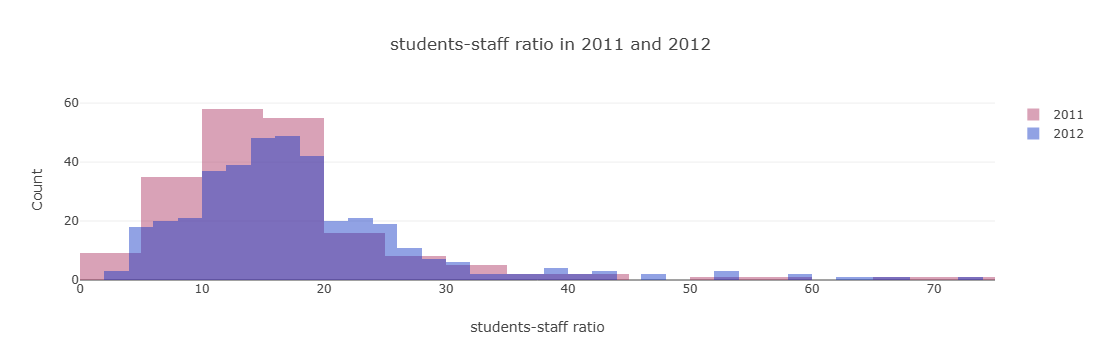

In [165]:
# prepare data
x2011 = timesData.student_staff_ratio[timesData.year == 2011]
x2012 = timesData.student_staff_ratio[timesData.year == 2012]

trace1 = go.Histogram(
    x=x2011,
    opacity=0.75,
    name = "2011",
    marker=dict(color='rgba(171, 50, 96, 0.6)'))

trace2 = go.Histogram(
    x=x2012,
    opacity=0.75,
    name = "2012",
    marker=dict(color='rgba(12, 50, 196, 0.6)'))

data = [trace1, trace2]

layout = go.Layout(barmode='overlay', # üst üste bindirme
                   title=' students-staff ratio in 2011 and 2012',
                   xaxis=dict(title='students-staff ratio'),
                   yaxis=dict( title='Count'),
)
fig = go.Figure(data=data, layout=layout)
iplot(fig)


# Word Cloud
Not a pyplot but learning it is good for visualization. Lets look at which country is mentioned most in 2011.
- 2011 yılındaki sıralamadaki en çok ismi geçen üniversiteleri yazdırıcaz.


* WordCloud = word cloud library that I import at the beginning of kernel
    * background_color = color of back ground
    * generate = generates the country name list(x2011) a word cloud

In [170]:
x2011= timesData.country[timesData.year == 2011]
x2011

0      United States of America
1      United States of America
2      United States of America
3      United States of America
4      United States of America
                 ...           
195    United States of America
196    United States of America
197                       China
198                      Canada
199                      Sweden
Name: country, Length: 200, dtype: object

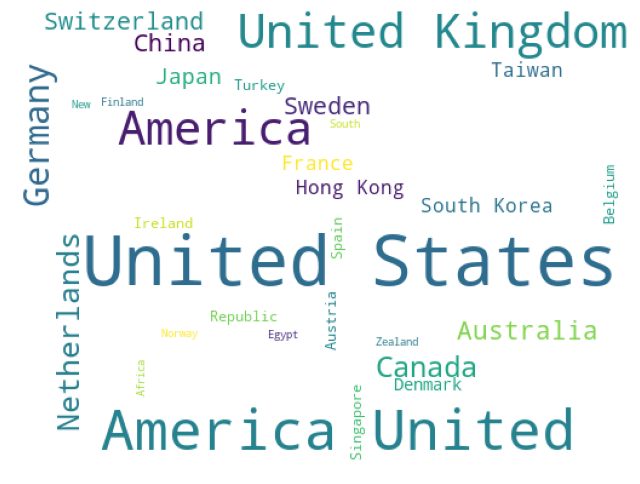

In [172]:
# data prepararion

x2011 = timesData.country[timesData.year == 2011]

plt.subplots(figsize=(8,8))

wordcloud = WordCloud(
                          background_color='white', # arkası beyaz olsun
                          width=512,
                          height=384
                         ).generate(" ".join(x2011)) # kelimeleri ayır ve en çok geçeni daha büyük yaz
plt.imshow(wordcloud)
plt.axis('off') # eksenleri kapatıyor
plt.savefig('graph1.png')

plt.show()

# datamın içine bak en sık geçenleri büyük yazdır. Az geçenleri ise küçük yazdır.

# Box Plots
<font color='red'>

* Box Plots
    * Median (50th percentile) = middle value of the data set. Sort and take the data in the middle. It is also called 50% percentile that is 50% of data are less that median(50th quartile)(quartile)
        * 25th percentile = quartile 1 (Q1) that is lower quartile
        * 75th percentile = quartile 3 (Q3) that is higher quartile
        * height of box = IQR = interquartile range = Q3-Q1
        * Whiskers = 1.5 * IQR from the Q1 and Q3
        * Outliers = being more than 1.5*IQR away from median commonly.
        
    <font color='black'>
    * trace = box
        
        * y = data we want to visualize with box plot 
        * marker = color

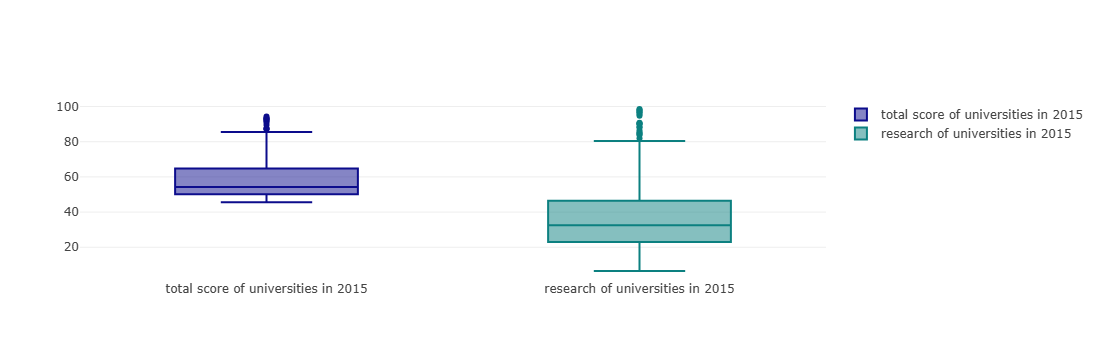

In [176]:
# data preparation
x2015 = timesData[timesData.year == 2015] # Datamız2015 yılındaki ilk 100 üni

trace0 = go.Box(
    y=x2015.total_score,
    name = 'total score of universities in 2015',
    marker = dict(
        color = 'rgb(12, 12, 140)',
    )
)
trace1 = go.Box(
    y=x2015.research,
    name = 'research of universities in 2015',
    marker = dict(
        color = 'rgb(12, 128, 128)',
    )
)
data = [trace0, trace1]
iplot(data)

# Scatter Matrix Plots
<font color='red'>
Scatter Matrix = it helps us to see covariance and relation between more than 2 features
    
<font color='black'>
    
* import figure factory as ff
* create_scatterplotmatrix = creates scatter plot
    * data2015 = prepared data. It includes research, international and total scores with index from 1 to 401
    * colormap = color map of scatter plot
    * colormap_type = color type of scatter plot
    * height and weight

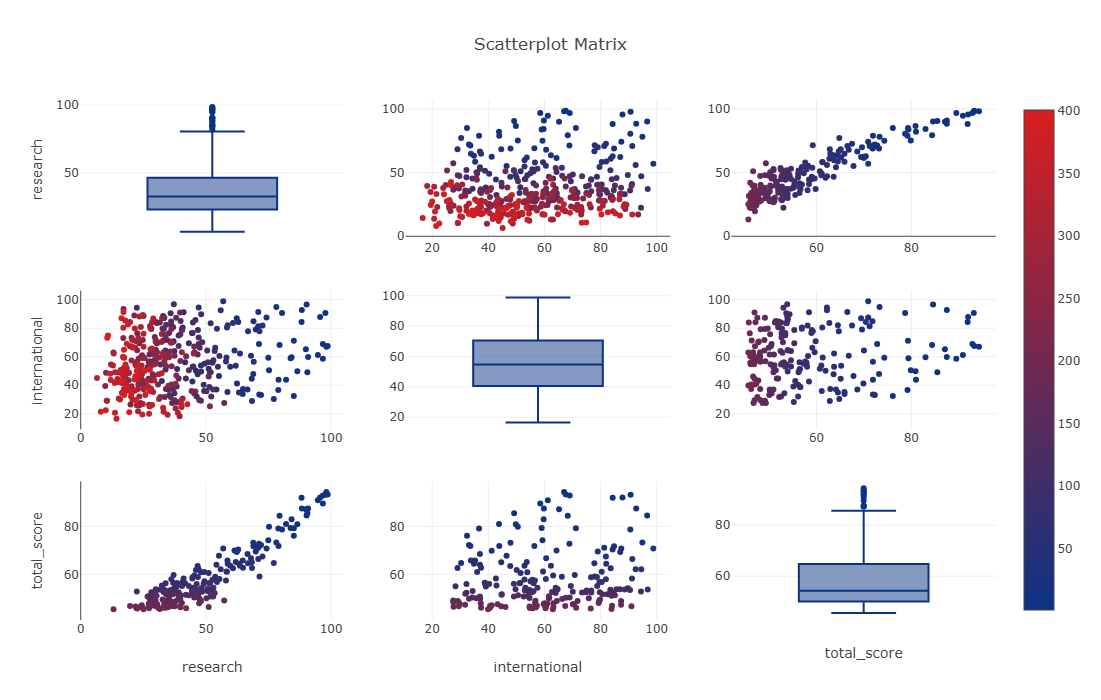

In [179]:
# import figure factory
import plotly.figure_factory as ff

# prepare data
dataframe = timesData[timesData.year == 2015]

data2015 = dataframe.loc[:,["research","international", "total_score"]] # karşılaştırmak istediğimiz featurlar
data2015["index"] = np.arange(1,len(data2015)+1) # dataframe uzunluğunda arange hesaplayıp indexine eşitliyoruz.


# scatter matrix
fig = ff.create_scatterplotmatrix(data2015, diag='box', index='index',colormap='Portland',
                                  colormap_type='cat',
                                  height=700, width=700)
iplot(fig)

In [185]:
# diagonal  
# research ile total_score arasında bağlantı var
# total_score ile international arasında bağlantı yok

In [187]:
data2015 # index featureı oluşturduk

,research,international,total_score,index
1402,98.1,67.0,94.3,1
1403,98.6,67.6,93.3,2
1404,97.7,90.7,93.2,3
1405,96.7,69.0,92.9,4
1406,95.6,87.8,92.0,5
...,...,...,...,...
1798,16.3,43.1,-,397
1799,27.5,36.0,-,398
1800,22.4,50.1,-,399
1801,17.4,33.1,-,400


# Inset Plots
<font color='red'>
Inset Matrix = 2 plots are in one frame
<font color='black'>

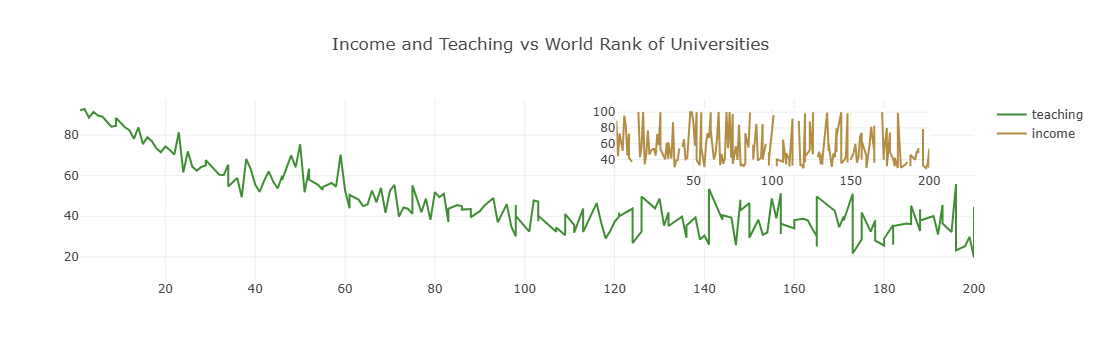

In [194]:
# first line plot
trace1 = go.Scatter(
    x=dataframe.world_rank,
    y=dataframe.teaching,
    name = "teaching",
    marker = dict(color = 'rgba(16, 112, 2, 0.8)'),
)


# second line plot
trace2 = go.Scatter(
    x=dataframe.world_rank,
    y=dataframe.income,
    xaxis='x2', # küçük plot
    yaxis='y2', # küçük plot
    name = "income",
    marker = dict(color = 'rgba(160, 112, 20, 0.8)'),
)


data = [trace1, trace2]


layout = go.Layout(
    # ikinci plotumuz için
    xaxis2=dict(
        domain=[0.6, 0.95],
        anchor='y2',        
    ),
    yaxis2=dict(
        domain=[0.6, 0.95],
        anchor='x2',
    ),
    title = 'Income and Teaching vs World Rank of Universities'

)


fig = go.Figure(data=data, layout=layout)
iplot(fig)


In [196]:
# bir frame üzerinde iki plot var. Vurgulanmak istenen plot büyük , yardımcı plot küçük.


# 3D Scatter Plot with Colorscaling
<font color='red'>
3D Scatter: Sometimes 2D is not enough to understand data. Therefore adding one more dimension increase the intelligibility of the data. Even we will add color that is actually 4th dimension.
<font color='black'>
    
* go.Scatter3d: create 3d scatter plot
* x,y,z: axis of plots
* mode: market that is scatter
* size: marker size
* color: axis of colorscale
* colorscale:  actually it is 4th dimension

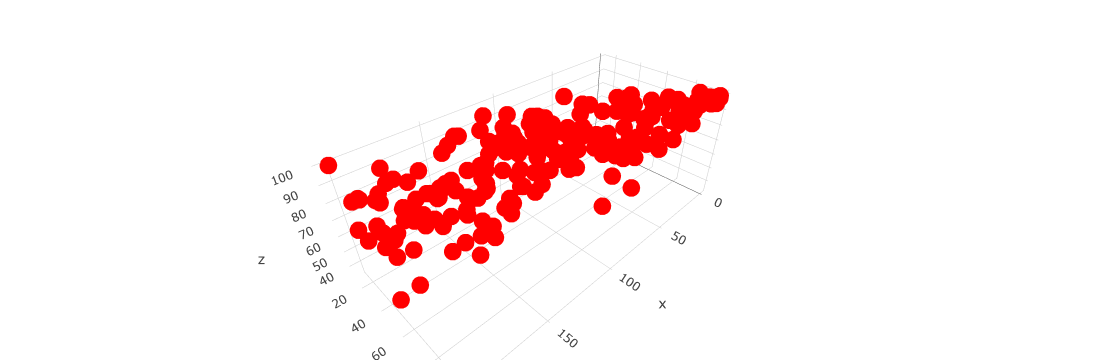

In [207]:
# create trace 1 that is 3d scatter
trace1 = go.Scatter3d(
    x=dataframe.world_rank,
    y=dataframe.research,
    z=dataframe.citations,
    mode='markers',
    marker=dict(
        size=10, # size = dataframe.income color = dataframe.world_rank 5 boyutlu mesela bu şekilde
        color='rgb(255,0,0)',# color scale = 'palegreen'        # set color to an array/list of desired values      
    )
)

data = [trace1]
layout = go.Layout(
    margin=dict( # kenarlarda bırakılan pay
        l=0,
        r=0,
        b=0,
        t=0  
    )
    
)
fig = go.Figure(data=data, layout=layout)
iplot(fig)

# Multiple Subplots
<font color='red'>
Multiple Subplots: While comparing more than one features, multiple subplots can be useful.
<font color='black'>
    
* Birden fazla görseli aynı featureın içine görselleştirmek istersek.

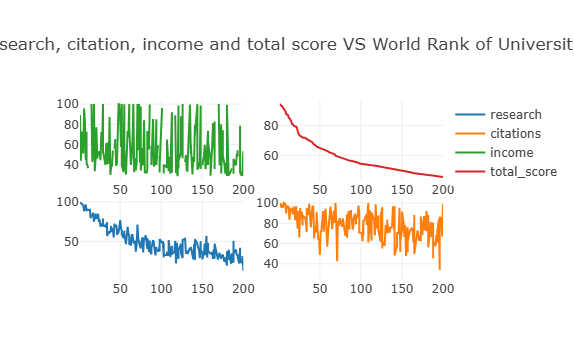

In [210]:
trace1 = go.Scatter(
    x=dataframe.world_rank,
    y=dataframe.research,
    name = "research"
)
trace2 = go.Scatter(
    x=dataframe.world_rank,
    y=dataframe.citations,
    xaxis='x2',
    yaxis='y2',
    name = "citations"
)
trace3 = go.Scatter(
    x=dataframe.world_rank,
    y=dataframe.income,
    xaxis='x3',
    yaxis='y3',
    name = "income"
)
trace4 = go.Scatter(
    x=dataframe.world_rank,
    y=dataframe.total_score,
    xaxis='x4',
    yaxis='y4',
    name = "total_score"
)
data = [trace1, trace2, trace3, trace4]
layout = go.Layout( # ilk trace harici diğer tracelerin bir domaini var.
    xaxis=dict(
        domain=[0, 0.45]
    ),
    yaxis=dict(
        domain=[0, 0.45]
    ),
    xaxis2=dict(
        domain=[0.55, 1]
    ),
    xaxis3=dict(
        domain=[0, 0.45],
        anchor='y3'
    ),
    xaxis4=dict(
        domain=[0.55, 1],
        anchor='y4'
    ),
    yaxis2=dict(
        domain=[0, 0.45],
        anchor='x2'
    ),
    yaxis3=dict(
        domain=[0.55, 1]
    ),
    yaxis4=dict(
        domain=[0.55, 1],
        anchor='x4'
    ),
    title = 'Research, citation, income and total score VS World Rank of Universities'
)
fig = go.Figure(data=data, layout=layout)
iplot(fig)

* map plotlar bir başka kernel üzerinden bakıcaz. Dünya haritası üzerinde görselleştirmeler yapıp nasıl linelar çizeceğimize bakıcaz.